# 实验4 神经网络的正则化

**任务：**  
**1. 定义并训练一个由3层线性分类器组成的神经网络，要求使用L2损失函数，中间层使用Relu作为激活函数，添加L2正则化项**  
**2. 添加dropout，再次训练测试，得出dropout的作用**  
**3. 进行数据增强，再次训练测试，得出数据增强的作用**

**思路：**  
**对于神经网络本身，我们既可以通过手写的方式实现，也可以使用高度封装好的第三方库来实现**  
**1. 对于任务1，按照题目要求实现即可**  
**2. 对于任务2，我们在任务1的基础上添加dropout即可，对比开启dropout和关闭dropout的训练结果即可得出其作用**  
**3. 对于任务3，我们通过对一个样本进行镜像翻转，添加一定的噪声来实现增多样本数的目的，样本数足够多可以缓解欠拟合和过拟合问题**

## 读取图像形式的MNIST
#划分为train/test  
#对数据进行归一化，即0-1之间，数据要变成float类型  
#把数据顺序打乱  
#注：若训练慢，可以减少训练图像数量

In [1]:
import gzip
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)
        labels=labels.astype(np.int32)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)
        images=images.astype(np.float32)/255.0  #Normalization

    temp=np.random.permutation(images.shape[0])  #乱序
    images=images[temp]
    labels=labels[temp]

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

# 读取训练集和测试集数据
[images, labels] = load_mnist('./MNIST', kind='train')
[test_img, test_lb] = load_mnist('./MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)


# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


## 使用手搓方式来实现任务1

**这里我们使用手写的方法来实现一个三层的MLP**  
**大致思路和实验2中的一样，损失函数改用L2，添加L2正则化项，但是暂时不启用dropout**

In [2]:
### 三层MLP类的定义

In [3]:
# 三层神经网络（带 Dropout + L2 正则 + He 初始化）
class ThreeLayerNet:
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, out_dim=10, lr=0.001,l2_lambda=0.001,keep_prob=0.9, use_dropout=False):
        # He 初始化，适用于选择Relu作为激活函数的场景
        self.W1 = np.random.randn(input_dim, hidden1) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, out_dim) * np.sqrt(2 / hidden2)
        self.b3 = np.zeros((1, out_dim))

        self.lr=lr
        self.l2_lambda=l2_lambda
        self.keep_prob = keep_prob
        self.use_dropout = use_dropout
        self.u1 = None
        self.u2 = None

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return np.where(x>0,1,0)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    # 前向传播（train=True 时开启 Dropout）
    def forward(self, x, train=False):
        z1 = np.dot(x,self.W1) + self.b1
        a1 = self.relu(z1)
        
        # Inverted Dropout
        if self.use_dropout and train:
            self.u1 = (np.random.rand(*a1.shape) < self.keep_prob) / self.keep_prob
            a1 *= self.u1

        z2 = np.dot(a1,self.W2) + self.b2
        a2 = self.relu(z2)
        
        if self.use_dropout and train:
            self.u2 = (np.random.rand(*a2.shape) < self.keep_prob) / self.keep_prob
            a2 *= self.u2

        z3 = np.dot(a2,self.W3) + self.b3
        a3 = self.softmax(z3)
        return z1, a1, z2, a2, a3

    # 损失函数：MSE + L2 正则
    def compute_loss(self, a3, y):
        loss_mse = np.mean(np.sum((a3 - y) ** 2, axis=1)) / 2
        loss_l2 =self.l2_lambda* (np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2)) / 2
        return loss_mse + loss_l2

    # 我们将反向传播和参数更新放到一起进行
    def backward(self, x, y, z1, a1, z2, a2, a3):
        m = x.shape[0]
        
        # 输出层
        dz3 = (a3 - y) / m
        dW3 = np.dot(a2.T,dz3)+self.l2_lambda*self.W3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        # 隐藏层 2
        da2 = np.dot(dz3,self.W3.T)
        if self.u2 is not None:
            da2 *= self.u2
        dz2 = da2 * self.relu_deriv(z2)
        dW2 = np.dot(a1.T,dz2) + self.l2_lambda * self.W2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # 隐藏层 1
        da1 = np.dot(dz2,self.W2.T)
        if self.u1 is not None:
            da1 *= self.u1
        dz1 = da1 * self.relu_deriv(z1)
        dW1 = np.dot(x.T,dz1) + self.l2_lambda* self.W1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 更新参数
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

In [4]:
def train(model, train_img, train_lb, val_img, val_lb,augment=False):

    epochs=50
    batch_size=64
    batch_num=train_img.shape[0]//batch_size
    onehot_train_lb = np.eye(10)[train_lb]
    onehot_val_lb = np.eye(10)[val_lb]

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0.0
        
        # 打乱数据
        idx = np.random.permutation(train_img.shape[0])
        train_img=train_img[idx]
        onehot_train_lb = onehot_train_lb[idx]

        for batch in range(batch_num):
            X=train_img[batch*batch_size:(batch+1)*batch_size]
            y = onehot_train_lb[batch*batch_size : (batch+1)*batch_size]

            if(augment):
                X=augment_img(X)

            z1, a1, z2, a2, a3 = model.forward(X, train=True)
            loss = model.compute_loss(a3, y)
            model.backward(X, y, z1, a1, z2, a2, a3)

            total_loss += loss
            correct += (np.argmax(a3, axis=1) == np.argmax(y, axis=1)).mean()

        # 训练集指标
        avg_loss = total_loss / batch_num
        avg_acc = correct / batch_num

        # 验证集
        _, _, _, _, val_a3 = model.forward(val_img, train=False) #_,表示我们不需要这个返回值
        val_loss = model.compute_loss(val_a3, onehot_val_lb)
        val_acc = (np.argmax(val_a3, axis=1) == val_lb).mean()

        # 保存曲线
        train_losses.append(avg_loss)
        train_accuracies.append(avg_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # 绘图
    plt.figure()
    plt.plot(np.arange(1,epochs+1),train_losses,color='red',label='Train Loss')
    plt.plot(np.arange(1,epochs+1),val_losses,color='blue',label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(np.arange(1,epochs+1),train_accuracies,color='red',label='Train Acc')
    plt.plot(np.arange(1,epochs+1),val_accuracies,color='blue',label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


### 训练模型并记录损失和准确率变化

Epoch  1 | Loss: 0.8035 | Acc: 0.3957 | Val Loss: 0.7475 | Val Acc: 0.6378
Epoch  2 | Loss: 0.6908 | Acc: 0.7162 | Val Loss: 0.6393 | Val Acc: 0.7708
Epoch  3 | Loss: 0.6034 | Acc: 0.7982 | Val Loss: 0.5761 | Val Acc: 0.8120
Epoch  4 | Loss: 0.5565 | Acc: 0.8313 | Val Loss: 0.5438 | Val Acc: 0.8341
Epoch  5 | Loss: 0.5313 | Acc: 0.8510 | Val Loss: 0.5252 | Val Acc: 0.8508
Epoch  6 | Loss: 0.5159 | Acc: 0.8641 | Val Loss: 0.5134 | Val Acc: 0.8603
Epoch  7 | Loss: 0.5057 | Acc: 0.8732 | Val Loss: 0.5047 | Val Acc: 0.8688
Epoch  8 | Loss: 0.4981 | Acc: 0.8800 | Val Loss: 0.4986 | Val Acc: 0.8738
Epoch  9 | Loss: 0.4925 | Acc: 0.8853 | Val Loss: 0.4938 | Val Acc: 0.8795
Epoch 10 | Loss: 0.4879 | Acc: 0.8898 | Val Loss: 0.4897 | Val Acc: 0.8844
Epoch 11 | Loss: 0.4842 | Acc: 0.8937 | Val Loss: 0.4864 | Val Acc: 0.8868
Epoch 12 | Loss: 0.4809 | Acc: 0.8968 | Val Loss: 0.4835 | Val Acc: 0.8901
Epoch 13 | Loss: 0.4782 | Acc: 0.8993 | Val Loss: 0.4809 | Val Acc: 0.8923
Epoch 14 | Loss: 0.4757 |

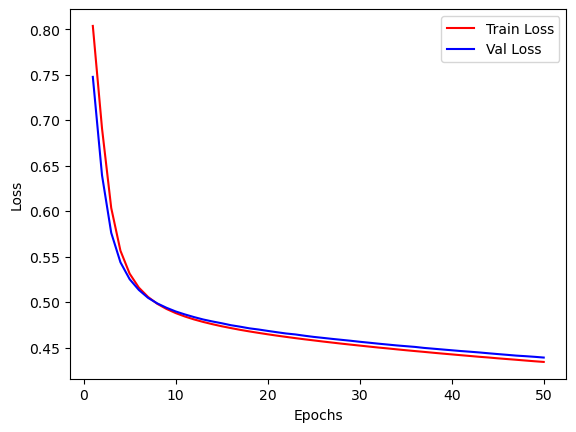

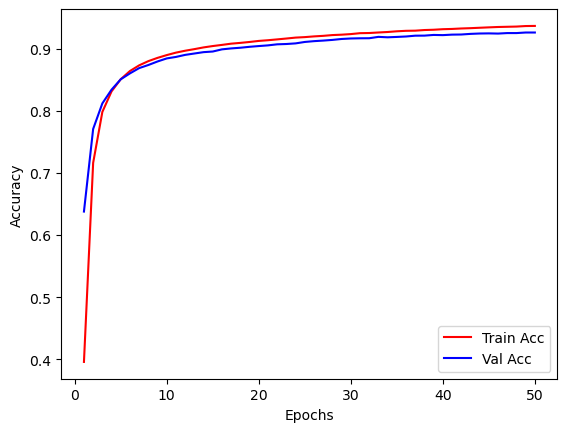

In [69]:
model = ThreeLayerNet(input_dim=784, hidden1=256, hidden2=128, out_dim=10,lr=0.001,l2_lambda=0.001,dropout_prob=0.9, use_dropout=False)
train(model, train_img, train_lb, val_img, val_lb)

**该任务相对简单，经过50轮迭代后，模型尚未表现出欠拟合和过拟合问题**  
**如果后续开启dropout之后，模型在训练集上的准确率略微下降，在验证集和测试集上的准确率略微上升，则可以证明模型的泛化能力增强了，从而说明dropout正确发挥了作用**

### 模型在测试集上的表现

In [70]:
_,_,_,_,a3=model.forward(test_img,train=False)
onehot_test_lb=np.eye(10)[test_lb]
loss=model.compute_loss(a3,onehot_test_lb)
accuracy=np.mean(np.argmax(a3,axis=1)==np.argmax(onehot_test_lb,axis=1))

print(f'The loss of model\'s prediction on Test Set : {loss:.4f}')
print(f'The accuracy of model\'s prediction on Test Set : {accuracy*100:.2f}%')

The loss of model's prediction on Test Set : 0.4341
The accuracy of model's prediction on Test Set : 93.61%


**模型在测试集上的准确率约为93.61%，尚有提升空间**

## 使用手搓方式来解决任务2

Epoch  1 | Loss: 0.8158 | Acc: 0.3306 | Val Loss: 0.7681 | Val Acc: 0.6259
Epoch  2 | Loss: 0.7251 | Acc: 0.6278 | Val Loss: 0.6625 | Val Acc: 0.7651
Epoch  3 | Loss: 0.6399 | Acc: 0.7324 | Val Loss: 0.5894 | Val Acc: 0.8139
Epoch  4 | Loss: 0.5902 | Acc: 0.7747 | Val Loss: 0.5512 | Val Acc: 0.8424
Epoch  5 | Loss: 0.5613 | Acc: 0.8036 | Val Loss: 0.5295 | Val Acc: 0.8548
Epoch  6 | Loss: 0.5445 | Acc: 0.8194 | Val Loss: 0.5161 | Val Acc: 0.8649
Epoch  7 | Loss: 0.5325 | Acc: 0.8313 | Val Loss: 0.5068 | Val Acc: 0.8708
Epoch  8 | Loss: 0.5234 | Acc: 0.8400 | Val Loss: 0.5000 | Val Acc: 0.8775
Epoch  9 | Loss: 0.5154 | Acc: 0.8504 | Val Loss: 0.4948 | Val Acc: 0.8812
Epoch 10 | Loss: 0.5098 | Acc: 0.8569 | Val Loss: 0.4906 | Val Acc: 0.8854
Epoch 11 | Loss: 0.5054 | Acc: 0.8609 | Val Loss: 0.4869 | Val Acc: 0.8881
Epoch 12 | Loss: 0.5012 | Acc: 0.8668 | Val Loss: 0.4839 | Val Acc: 0.8901
Epoch 13 | Loss: 0.4978 | Acc: 0.8693 | Val Loss: 0.4812 | Val Acc: 0.8930
Epoch 14 | Loss: 0.4950 |

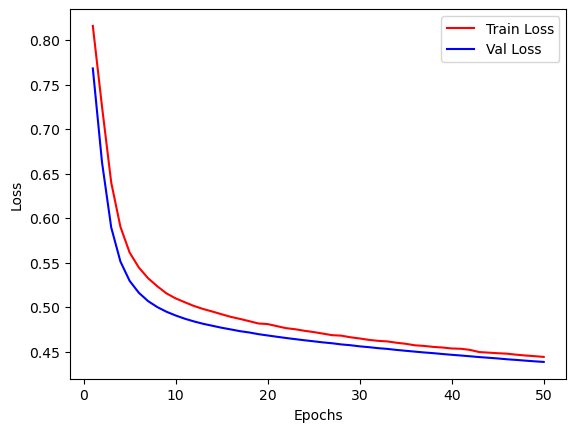

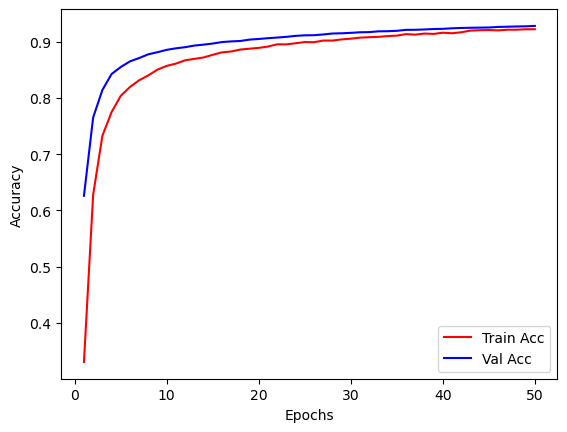

In [73]:
model = ThreeLayerNet(input_dim=784, hidden1=256, hidden2=128, out_dim=10,lr=0.001,l2_lambda=0.001,dropout_prob=0.9, use_dropout=True)
train(model, train_img, train_lb, val_img, val_lb)

**启用dropout之后，可以明显看出测试集准确率和验证集准确率的差值变大了，说明dropout抑制了模型对训练集某些特征的学习**

### 模型在测试集上的表现

In [75]:
_,_,_,_,a3=model.forward(test_img,train=False)
onehot_test_lb=np.eye(10)[test_lb]
loss=model.compute_loss(a3,onehot_test_lb)
accuracy=np.mean(np.argmax(a3,axis=1)==np.argmax(onehot_test_lb,axis=1))

print(f'The loss of model\'s prediction on Test Set : {loss:.4f}')
print(f'The accuracy of model\'s prediction on Test Set : {accuracy*100:.2f}%')

The loss of model's prediction on Test Set : 0.4326
The accuracy of model's prediction on Test Set : 93.81%


**启用dropout之后，模型在验证集上的准确率约为93.81%，相比之前有了一些提高，说明dropout起到了一些作用**

## 对MNIST数据集进行数据增强

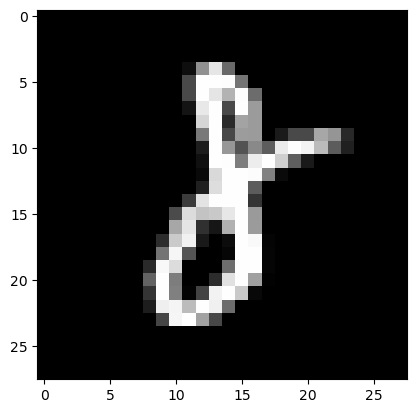

In [17]:
#随机选取一张一个样本
random_idx=666
random_img=train_img[random_idx].reshape(28,28)  #画出灰度图需要保证尺寸合适，形状为(784,)的向量是不能直接画出来的
plt.imshow(random_img, cmap='gray', interpolation='nearest')  #注意cmap='gray'，否则画出来不是灰度图


In [5]:
from scipy.ndimage import rotate, shift  #记得导包

def augment_image(img):
    """
    对单张 MNIST 图像(28x28)做随机增强
    返回增强后的图像（依然是 28x28）
    """
    # 把展平的 784 恢复成 28x28
    img_28 = img.reshape(28, 28)
    
    #上下左右随机平移-2 ~ 2像素
    dx = np.random.randint(-1, 2)
    dy = np.random.randint(-1, 2)
    img_aug = shift(img_28, [dx, dy], mode='constant', cval=0)
    
    #随机旋转-10° ~ 10°
    angle = np.random.randint(-10, 11)
    img_aug = rotate(img_aug, angle, reshape=False, mode='constant', cval=0)
    
    # 转回 784 向量
    return img_aug.flatten()

def augment_img(imgs):
    return np.array([augment_image(img) for img in imgs])

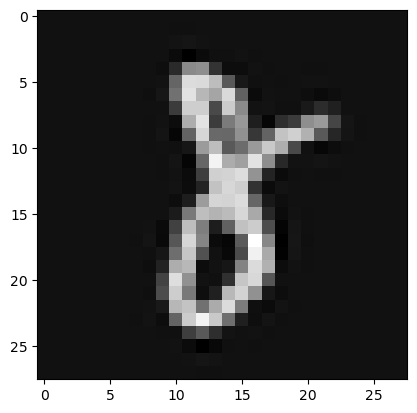

In [37]:
#来看看之前那个样本经过数据增强之后发生了什么变化
random_img_reinforce=augment_image(random_img).reshape(28,28)
plt.imshow(random_img_reinforce,cmap='gray', interpolation='nearest')

**可以看到，这张图片沿逆时针方向旋转了一些，现在我们试着来对整个数据集进行增强**

Epoch  1 | Loss: 0.8241 | Acc: 0.2433 | Val Loss: 0.7811 | Val Acc: 0.5317
Epoch  2 | Loss: 0.7672 | Acc: 0.4820 | Val Loss: 0.7025 | Val Acc: 0.7146
Epoch  3 | Loss: 0.7101 | Acc: 0.5998 | Val Loss: 0.6337 | Val Acc: 0.7798
Epoch  4 | Loss: 0.6670 | Acc: 0.6525 | Val Loss: 0.5873 | Val Acc: 0.8147
Epoch  5 | Loss: 0.6371 | Acc: 0.6836 | Val Loss: 0.5573 | Val Acc: 0.8369
Epoch  6 | Loss: 0.6178 | Acc: 0.7064 | Val Loss: 0.5378 | Val Acc: 0.8514
Epoch  7 | Loss: 0.6013 | Acc: 0.7270 | Val Loss: 0.5245 | Val Acc: 0.8594
Epoch  8 | Loss: 0.5911 | Acc: 0.7389 | Val Loss: 0.5144 | Val Acc: 0.8682
Epoch  9 | Loss: 0.5820 | Acc: 0.7498 | Val Loss: 0.5065 | Val Acc: 0.8746
Epoch 10 | Loss: 0.5747 | Acc: 0.7615 | Val Loss: 0.5004 | Val Acc: 0.8799
Epoch 11 | Loss: 0.5672 | Acc: 0.7724 | Val Loss: 0.4953 | Val Acc: 0.8866
Epoch 12 | Loss: 0.5614 | Acc: 0.7795 | Val Loss: 0.4908 | Val Acc: 0.8899
Epoch 13 | Loss: 0.5575 | Acc: 0.7834 | Val Loss: 0.4871 | Val Acc: 0.8938
Epoch 14 | Loss: 0.5527 |

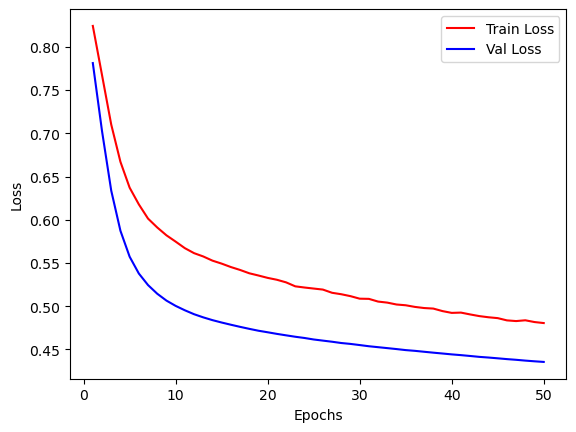

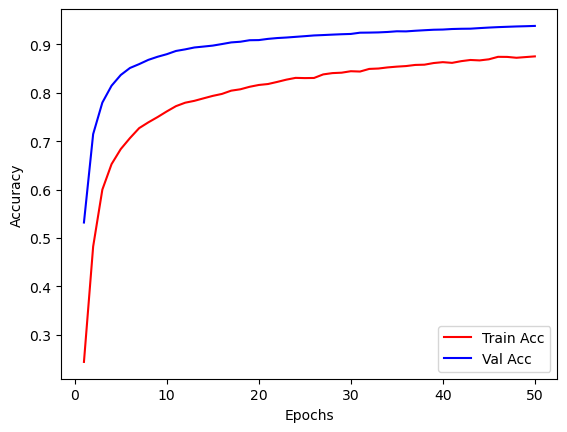

In [7]:
model = ThreeLayerNet(input_dim=784, hidden1=256, hidden2=128, out_dim=10,lr=0.001,l2_lambda=0.001,keep_prob=0.9, use_dropout=True)
train(model, train_img, train_lb, val_img, val_lb,augment=True)

**可以看到，训练集准确率和验证集准确率差距进一步增大，且50轮迭代之后验证集准确率比起没有使用数据增强时有了显著的提升**  
**这说明模型的泛化能力得到了增强，这是因为我们在训练时几乎一直使用的都是不重复的样本，海量的新数据有效避免了模型的过拟合**

### 数据增强之后，模型在测试集上的表现

In [8]:
_,_,_,_,a3=model.forward(test_img,train=False)
onehot_test_lb=np.eye(10)[test_lb]
loss=model.compute_loss(a3,onehot_test_lb)
accuracy=np.mean(np.argmax(a3,axis=1)==np.argmax(onehot_test_lb,axis=1))

print(f'The loss of model\'s prediction on Test Set : {loss:.4f}')
print(f'The accuracy of model\'s prediction on Test Set : {accuracy*100:.2f}%')

The loss of model's prediction on Test Set : 0.4324
The accuracy of model's prediction on Test Set : 94.39%


**可以看到，此时模型在测试集上的准确率已经到了94%左右，相比之前有了显著的提升**

In [ ]:
#完结撒花#
#*********************************************
#                   _ooOoo_
#                  o8888888o
#                  88" . "88
#                  (| -_- |)
#                 O\  =  /O
#               ____/`---'\____
#             .'  \\|     |//  `.
#            /  \\|||  :  |||//  \
#           /  _||||| -:- |||||-  \
#           |   | \\\  -  /// |   |
#           | \_|  ''\---/''  |   |
#           \  .-\__  `-`  ___/-. /
#         ___`. .'  /--.--\  `. . __
#      ."" '<  `.___\_<|>_/___.'  >'"".
#     | | :  `- \`.;`\ _ /`;.`/ - ` : | |
#     \  \ `-.   \_ __\ /__ _/   .-` /  /
#======`-.____`-.___\_____/___.-`____.-'======
#                   `=---='
#^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#           佛祖保佑       永无BUG